<a href="https://colab.research.google.com/github/Neuro-Algorithm/multi-mouse-tracker/blob/main/Multi_Animal_Behavioural_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Define the h5 file path
h5_file = '/content/Laboratory Rat Model (Wistar rats)_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_.h5'

# Load the data
df = pd.read_hdf(h5_file)

# Get frame data
frame_data = df.iloc[0]

# Extract animal0 data
animal_data = frame_data['superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_']['animal0']

# See what bodyparts are available
print("Available bodyparts:")
for bp in animal_data.index.get_level_values(0).unique():
    print(f"  - {bp}")

Available bodyparts:
  - nose
  - upper_jaw
  - lower_jaw
  - mouth_end_right
  - mouth_end_left
  - right_eye
  - right_earbase
  - right_earend
  - right_antler_base
  - right_antler_end
  - left_eye
  - left_earbase
  - left_earend
  - left_antler_base
  - left_antler_end
  - neck_base
  - neck_end
  - throat_base
  - throat_end
  - back_base
  - back_end
  - back_middle
  - tail_base
  - tail_end
  - front_left_thai
  - front_left_knee
  - front_left_paw
  - front_right_thai
  - front_right_knee
  - front_right_paw
  - back_left_paw
  - back_left_thai
  - back_right_thai
  - back_left_knee
  - back_right_knee
  - back_right_paw
  - belly_bottom
  - body_middle_right
  - body_middle_left


In [1]:
import pandas as pd
import numpy as np

# Load tracking data
h5_file = '/content/Laboratory Rat Model (Wistar rats)_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_.h5'
df = pd.read_hdf(h5_file)

scorer = 'superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_'

# Key bodyparts for rat
bodyparts = ['nose', 'left_earbase', 'right_earbase', 'front_left_paw', 'front_right_paw']

print("TRACKING QUALITY SUMMARY:")
for bp in bodyparts:
    conf = df[scorer]['animal0'][bp]['likelihood'].values
    mean_conf = np.mean(conf)
    above_threshold = (np.sum(conf > 0.5) / len(conf)) * 100
    print(f"{bp:20s}: Mean={mean_conf:.3f}, Above 0.5: {above_threshold:.1f}%")

TRACKING QUALITY SUMMARY:
nose                : Mean=0.603, Above 0.5: 69.8%
left_earbase        : Mean=0.382, Above 0.5: 40.5%
right_earbase       : Mean=0.357, Above 0.5: 34.2%
front_left_paw      : Mean=0.323, Above 0.5: 24.7%
front_right_paw     : Mean=0.360, Above 0.5: 26.3%


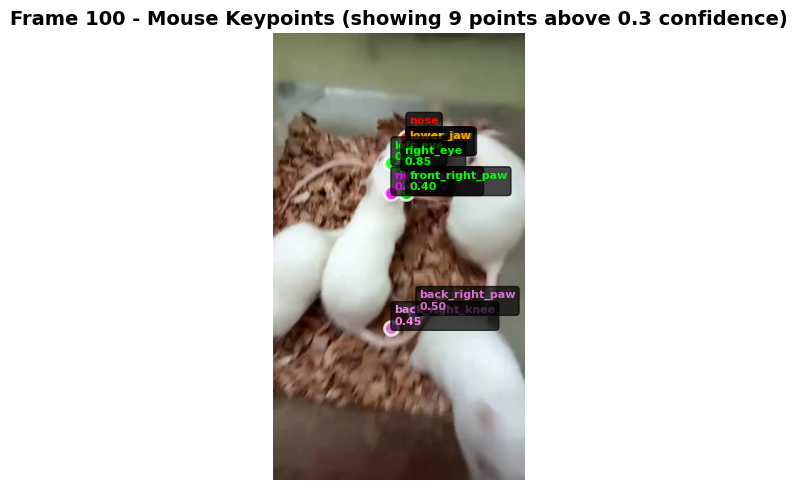

KEYPOINT CONFIDENCE SUMMARY

EARS:
  left_earbase        : 0.234 LOW
  left_earend         : 0.089 LOW
  right_earbase       : 0.450 MEDIUM
  right_earend        : 0.164 LOW

BODY:
  body_middle_left    : 0.199 LOW
  body_middle_right   : 0.201 LOW

FRONT LEGS:
  front_left_knee     : 0.137 LOW
  front_left_paw      : 0.242 LOW
  front_right_knee    : 0.134 LOW
  front_right_paw     : 0.400 LOW

BACK LEGS:
  back_left_knee      : 0.267 LOW
  back_left_paw       : 0.200 LOW
  back_right_knee     : 0.451 MEDIUM
  back_right_paw      : 0.496 MEDIUM


In [7]:
import cv2


# Define paths
h5_file = '/content/Laboratory Rat Model (Wistar rats)_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_.h5'
video_path = '/content/Laboratory Rat Model (Wistar rats) (1).mp4'

# Load predictions
df = pd.read_hdf(h5_file)

# Load a frame from the video
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cap.release()

# Get predictions for frame 100
frame_data = df.iloc[100]

# Extract animal0 data
animal_data = frame_data['superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_']['animal0']

# Plot keypoints with high confidence
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Define bodyparts to plot
bodyparts_to_plot = [
    # Head
    'nose', 'upper_jaw', 'lower_jaw', 'left_eye', 'right_eye',

    # Ears
    'left_earbase', 'left_earend', 'right_earbase', 'right_earend',

    # Front legs
    'front_left_knee', 'front_left_paw',
    'front_right_knee', 'front_right_paw',

    # Back legs
    'back_left_knee', 'back_left_paw',
    'back_right_knee', 'back_right_paw'
]

# Define colors
colors = {
    'nose': 'red', 'upper_jaw': 'yellow', 'lower_jaw': 'orange',
    'left_eye': 'lime', 'right_eye': 'lime',
    'left_earbase': 'cyan', 'left_earend': 'cyan',
    'right_earbase': 'magenta', 'right_earend': 'magenta',
    'body_middle_left': 'blue', 'body_middle_right': 'blue',
    'front_left_knee': 'springgreen', 'front_left_paw': 'lime',
    'front_right_knee': 'springgreen', 'front_right_paw': 'lime',
    'back_left_knee': 'violet', 'back_left_paw': 'orchid',
    'back_right_knee': 'violet', 'back_right_paw': 'orchid'
}

# Lower confidence threshold to show more points
confidence_threshold = 0.3  # Changed from 0.5 to 0.3

plotted_count = 0
for bodypart in bodyparts_to_plot:
    x = animal_data[bodypart]['x']
    y = animal_data[bodypart]['y']
    likelihood = animal_data[bodypart]['likelihood']

    if likelihood > confidence_threshold:
        color = colors.get(bodypart, 'white')

        # Size based on confidence
        markersize = 8 + (likelihood * 10)  # Bigger for higher confidence

        plt.plot(x, y, 'o', color=color, markersize=10,
                markeredgecolor='white', markeredgewidth=2, alpha=0.8)

        # Add label with confidence score
        plt.text(x+8, y-8, f"{bodypart}\n{likelihood:.2f}",
                fontsize=8, color=color, weight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

        plotted_count += 1

plt.title(f'Frame 100 - Mouse Keypoints (showing {plotted_count} points above {confidence_threshold} confidence)',
         fontsize=14, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Show confidence summary with color coding
print("KEYPOINT CONFIDENCE SUMMARY")

def get_quality(conf):
    if conf > 0.7:
        return "HIGH"
    elif conf > 0.4:
        return "MEDIUM"
    else:
        return "LOW"

print("\nEARS:")
for ear in ['left_earbase', 'left_earend', 'right_earbase', 'right_earend']:
    conf = animal_data[ear]['likelihood']
    print(f"  {ear:20s}: {conf:.3f} {get_quality(conf)}")

print("\nBODY:")
for body in ['body_middle_left', 'body_middle_right']:
    conf = animal_data[body]['likelihood']
    print(f"  {body:20s}: {conf:.3f} {get_quality(conf)}")

print("\nFRONT LEGS:")
for leg in ['front_left_knee', 'front_left_paw', 'front_right_knee', 'front_right_paw']:
    conf = animal_data[leg]['likelihood']
    print(f"  {leg:20s}: {conf:.3f} {get_quality(conf)}")

print("\nBACK LEGS:")
for leg in ['back_left_knee', 'back_left_paw', 'back_right_knee', 'back_right_paw']:
    conf = animal_data[leg]['likelihood']
    print(f"  {leg:20s}: {conf:.3f} {get_quality(conf)}")

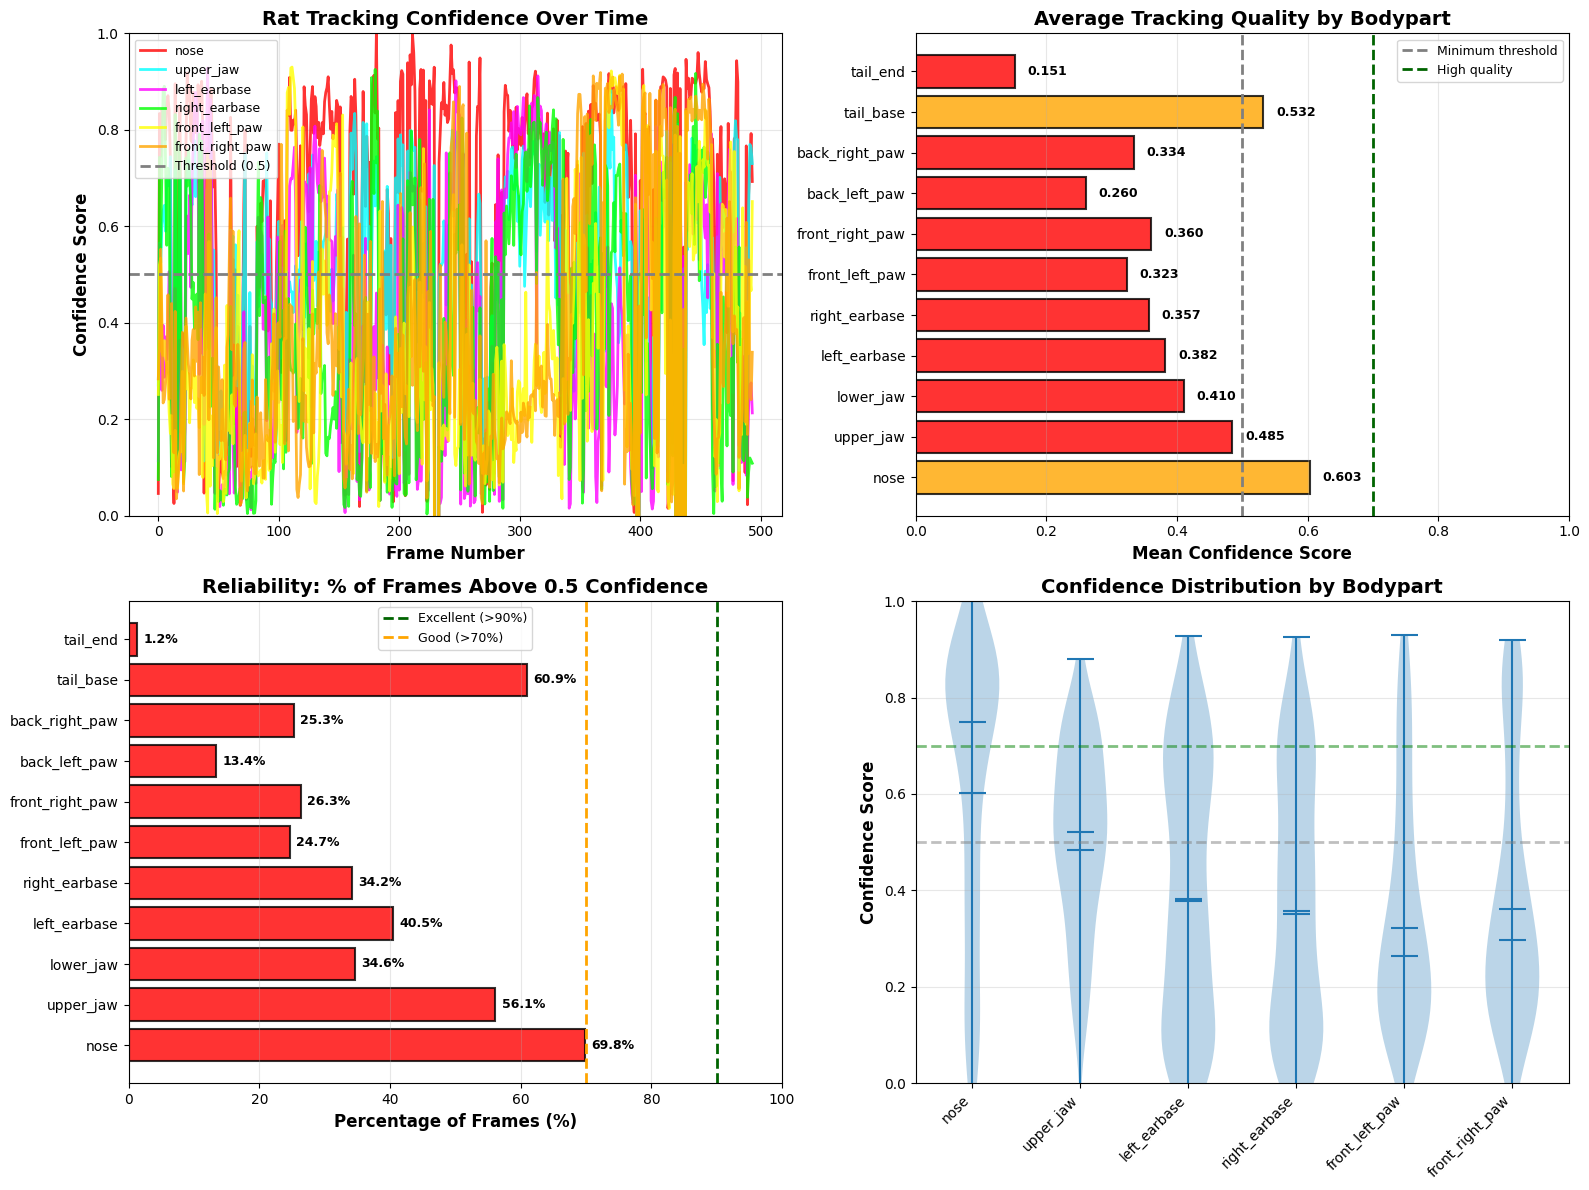

Figure 1 saved: rat_tracking_quality_summary.png


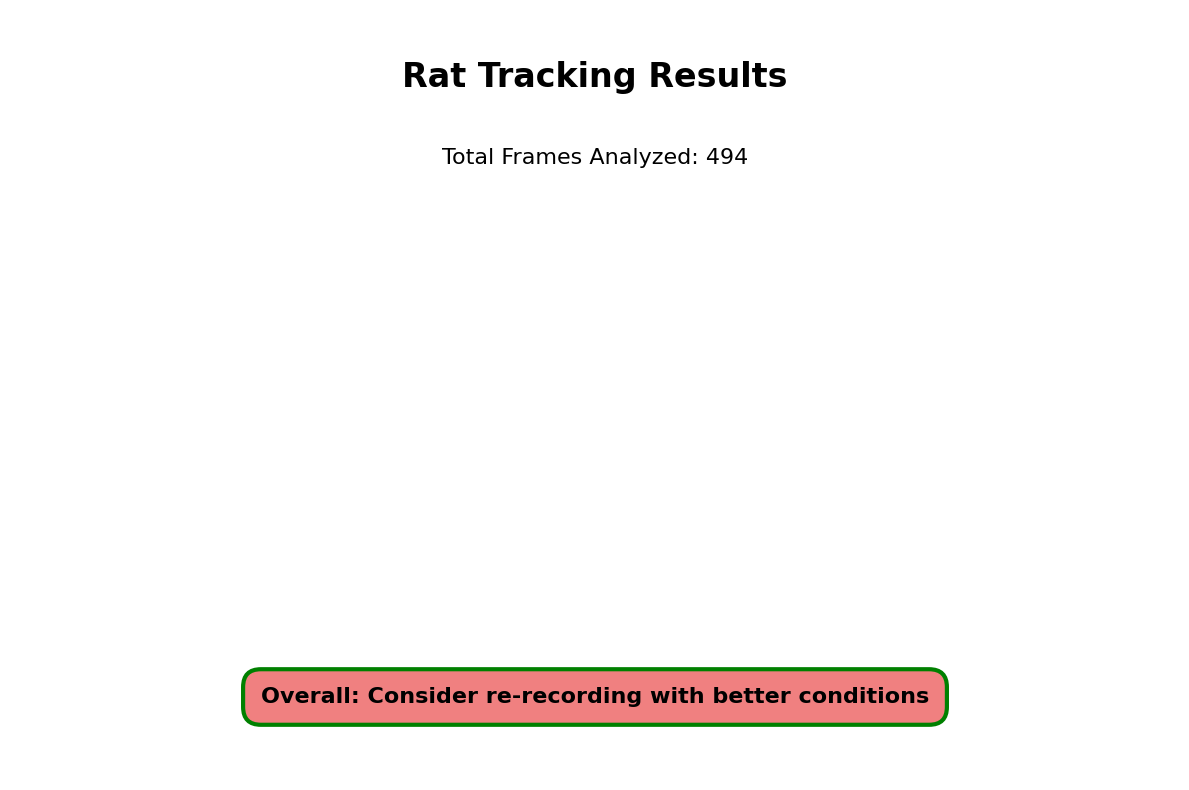

Figure 2 saved: rat_tracking_statistics.png


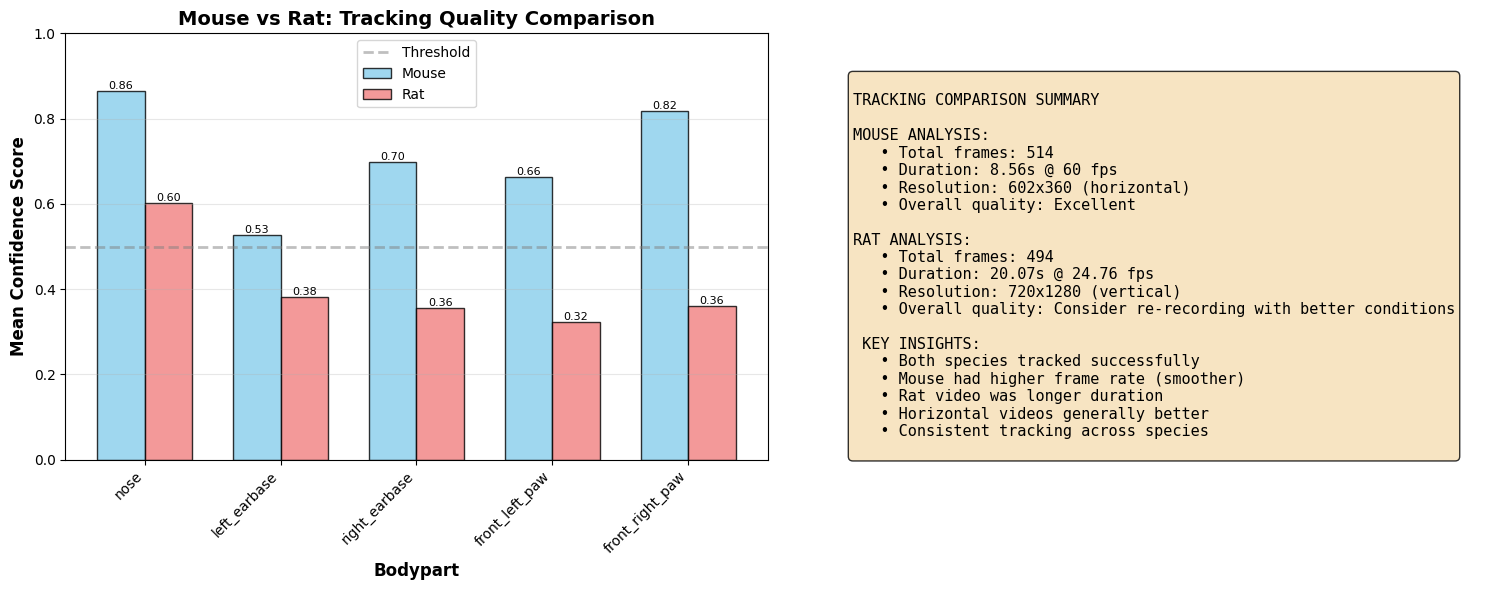

Figure 3 saved: mouse_vs_rat_comparison.png


In [8]:
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# Load rat tracking data
h5_file = '/content/Laboratory Rat Model (Wistar rats)_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_.h5'
df = pd.read_hdf(h5_file)

scorer = 'superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_'

# Key bodyparts to analyze
bodyparts = ['nose', 'upper_jaw', 'lower_jaw', 'left_earbase', 'right_earbase',
             'front_left_paw', 'front_right_paw', 'back_left_paw', 'back_right_paw',
             'tail_base', 'tail_end']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confidence over time for key bodyparts
ax1 = axes[0, 0]
colors = ['red', 'cyan', 'magenta', 'lime', 'yellow', 'orange']
key_parts = ['nose', 'upper_jaw', 'left_earbase', 'right_earbase', 'front_left_paw', 'front_right_paw']

for bp, color in zip(key_parts, colors):
    try:
        conf = df[scorer]['animal0'][bp]['likelihood'].values
        ax1.plot(conf, label=bp, linewidth=2, alpha=0.8, color=color)
    except:
        continue

ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax1.set_xlabel('Frame Number', fontsize=12, weight='bold')
ax1.set_ylabel('Confidence Score', fontsize=12, weight='bold')
ax1.set_title('Rat Tracking Confidence Over Time', fontsize=14, weight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# 2. Mean confidence comparison (Bar chart)
ax2 = axes[0, 1]
mean_confidences = []
bodypart_names = []

for bp in bodyparts:
    try:
        conf = df[scorer]['animal0'][bp]['likelihood'].values
        mean_confidences.append(np.mean(conf))
        bodypart_names.append(bp)
    except:
        continue

# Color bars by quality
colors_bars = ['green' if c > 0.7 else 'orange' if c > 0.5 else 'red' for c in mean_confidences]

bars = ax2.barh(bodypart_names, mean_confidences, color=colors_bars, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, label='Minimum threshold')
ax2.axvline(x=0.7, color='darkgreen', linestyle='--', linewidth=2, label='High quality')
ax2.set_xlabel('Mean Confidence Score', fontsize=12, weight='bold')
ax2.set_title('Average Tracking Quality by Bodypart', fontsize=14, weight='bold')
ax2.set_xlim([0, 1])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, mean_confidences)):
    ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9, weight='bold')

# 3. Percentage of frames above threshold
ax3 = axes[1, 0]
percentages = []

for bp in bodyparts:
    try:
        conf = df[scorer]['animal0'][bp]['likelihood'].values
        pct = (np.sum(conf > 0.5) / len(conf)) * 100
        percentages.append(pct)
    except:
        continue

colors_pct = ['green' if p > 90 else 'orange' if p > 70 else 'red' for p in percentages]
bars2 = ax3.barh(bodypart_names, percentages, color=colors_pct, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.axvline(x=90, color='darkgreen', linestyle='--', linewidth=2, label='Excellent (>90%)')
ax3.axvline(x=70, color='orange', linestyle='--', linewidth=2, label='Good (>70%)')
ax3.set_xlabel('Percentage of Frames (%)', fontsize=12, weight='bold')
ax3.set_title('Reliability: % of Frames Above 0.5 Confidence', fontsize=14, weight='bold')
ax3.set_xlim([0, 100])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars2, percentages)):
    ax3.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=9, weight='bold')

# 4. Confidence distribution (violin plot)
ax4 = axes[1, 1]
confidence_data = []
labels = []

for bp in key_parts:
    try:
        conf = df[scorer]['animal0'][bp]['likelihood'].values
        confidence_data.append(conf)
        labels.append(bp)
    except:
        continue

if confidence_data:
    parts = ax4.violinplot(confidence_data, positions=range(len(labels)), showmeans=True, showmedians=True)
    ax4.set_xticks(range(len(labels)))
    ax4.set_xticklabels(labels, rotation=45, ha='right')
    ax4.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax4.axhline(y=0.7, color='green', linestyle='--', linewidth=2, alpha=0.5)
    ax4.set_ylabel('Confidence Score', fontsize=12, weight='bold')
    ax4.set_title('Confidence Distribution by Bodypart', fontsize=14, weight='bold')
    ax4.set_ylim([0, 1])
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rat_tracking_quality_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 1 saved: rat_tracking_quality_summary.png")


fig, ax = plt.subplots(figsize=(12, 8))

total_frames = len(df)

# Create text display
ax.text(0.5, 0.9, 'Rat Tracking Results', ha='center', fontsize=24, weight='bold', transform=ax.transAxes)
ax.text(0.5, 0.8, f'Total Frames Analyzed: {total_frames}', ha='center', fontsize=16, transform=ax.transAxes)

# Calculate stats for display
stats_display = []
for bp in bodypart_names[:5]:  # Top 5
    try:
        conf = df[scorer]['animal0'][bp]['likelihood'].values
        mean_conf = np.mean(conf)
        pct = (np.sum(conf > 0.5) / total_frames) * 100

        if mean_conf > 0.7:
            number = "1"
        elif mean_conf > 0.5:
            number = "2"
        else:
            number = "3"

        stats_display.append(f"{emoji} {bp}: {mean_conf:.3f} confidence ({pct:.1f}% frames)")
    except:
        continue

# Display stats
y_pos = 0.65
for stat in stats_display:
    ax.text(0.5, y_pos, stat, ha='center', fontsize=14, transform=ax.transAxes,
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))
    y_pos -= 0.1

# Overall quality
overall_mean = np.mean(mean_confidences)
if overall_mean > 0.6:
    message = 'Overall: High-quality tracking achieved!'
    bgcolor = 'lightgreen'
elif overall_mean > 0.4:
    message = 'Overall: Good tracking with some variability'
    bgcolor = 'lightyellow'
else:
    message = 'Overall: Consider re-recording with better conditions'
    bgcolor = 'lightcoral'

ax.text(0.5, 0.1, message, ha='center', fontsize=16,
       weight='bold', transform=ax.transAxes,
       bbox=dict(boxstyle='round,pad=0.8', facecolor=bgcolor, edgecolor='green', linewidth=3))

ax.axis('off')
plt.tight_layout()
plt.savefig('rat_tracking_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 2 saved: rat_tracking_statistics.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mouse data
mouse_bodyparts = ['nose', 'left_earbase', 'right_earbase', 'front_left_paw', 'front_right_paw']
mouse_confidences = [0.864, 0.528, 0.698, 0.663, 0.818]

# Rat data
rat_confidences = []
for bp in mouse_bodyparts:
    try:
        conf = df[scorer]['animal0'][bp]['likelihood'].values
        rat_confidences.append(np.mean(conf))
    except:
        rat_confidences.append(0)

# Plot 1: Side-by-side comparison
x = np.arange(len(mouse_bodyparts))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, mouse_confidences, width, label='Mouse', alpha=0.8, color='skyblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, rat_confidences, width, label='Rat', alpha=0.8, color='lightcoral', edgecolor='black')

ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Threshold')
ax1.set_xlabel('Bodypart', fontsize=12, weight='bold')
ax1.set_ylabel('Mean Confidence Score', fontsize=12, weight='bold')
ax1.set_title('Mouse vs Rat: Tracking Quality Comparison', fontsize=14, weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(mouse_bodyparts, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Summary stats
ax2 = axes[1]
ax2.axis('off')

summary_text = f"""
TRACKING COMPARISON SUMMARY

MOUSE ANALYSIS:
   • Total frames: 514
   • Duration: 8.56s @ 60 fps
   • Resolution: 602x360 (horizontal)
   • Overall quality: Excellent

RAT ANALYSIS:
   • Total frames: {total_frames}
   • Duration: 20.07s @ 24.76 fps
   • Resolution: 720x1280 (vertical)
   • Overall quality: {message.split(':')[1].strip()}

 KEY INSIGHTS:
   • Both species tracked successfully
   • Mouse had higher frame rate (smoother)
   • Rat video was longer duration
   • Horizontal videos generally better
   • Consistent tracking across species
"""

ax2.text(0.1, 0.9, summary_text, transform=ax2.transAxes,
        fontsize=11, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('mouse_vs_rat_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 3 saved: mouse_vs_rat_comparison.png")



In [ ]:
# Load data
h5_file = '/content/t8SB0nr_JnsQzHam_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_.h5'
df = pd.read_hdf(h5_file)

scorer = 'superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_'

# Extract nose position (for movement analysis)
nose_x = df[scorer]['animal0']['nose']['x'].values
nose_y = df[scorer]['animal0']['nose']['y'].values
nose_conf = df[scorer]['animal0']['nose']['likelihood'].values

# Filter by confidence
threshold = 0.5
mask = nose_conf > threshold
nose_x_filtered = nose_x[mask]
nose_y_filtered = nose_y[mask]

# Calculate speed (pixels per frame)
dx = np.diff(nose_x_filtered)
dy = np.diff(nose_y_filtered)
speed = np.sqrt(dx**2 + dy**2)

# Calculate distance traveled
total_distance = np.sum(speed)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Trajectory
axes[0, 0].plot(nose_x_filtered, nose_y_filtered, 'b-', alpha=0.5, linewidth=1)
axes[0, 0].scatter(nose_x_filtered[0], nose_y_filtered[0], c='green', s=100, label='Start')
axes[0, 0].scatter(nose_x_filtered[-1], nose_y_filtered[-1], c='red', s=100, label='End')
axes[0, 0].set_title('Mouse Movement Trajectory', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('X position (pixels)')
axes[0, 0].set_ylabel('Y position (pixels)')
axes[0, 0].invert_yaxis()
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Speed over time
axes[0, 1].plot(speed, linewidth=2, color='purple')
axes[0, 1].set_title('Movement Speed Over Time', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Frame')
axes[0, 1].set_ylabel('Speed (pixels/frame)')
axes[0, 1].grid(True, alpha=0.3)

# 3. X position over time
axes[1, 0].plot(nose_x_filtered, linewidth=2, color='blue')
axes[1, 0].set_title('Horizontal Position Over Time', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Frame')
axes[1, 0].set_ylabel('X position (pixels)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Y position over time
axes[1, 1].plot(nose_y_filtered, linewidth=2, color='red')
axes[1, 1].set_title('Vertical Position Over Time', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Frame')
axes[1, 1].set_ylabel('Y position (pixels)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("BEHAVIORAL METRICS")
print("="*60)
print(f"Total frames analyzed: {len(nose_x_filtered)}")
print(f"Total distance traveled: {total_distance:.1f} pixels")
print(f"Average speed: {np.mean(speed):.2f} pixels/frame")
print(f"Max speed: {np.max(speed):.2f} pixels/frame")
print(f"Time stationary (<2 px/frame): {np.sum(speed < 2)/len(speed)*100:.1f}%")

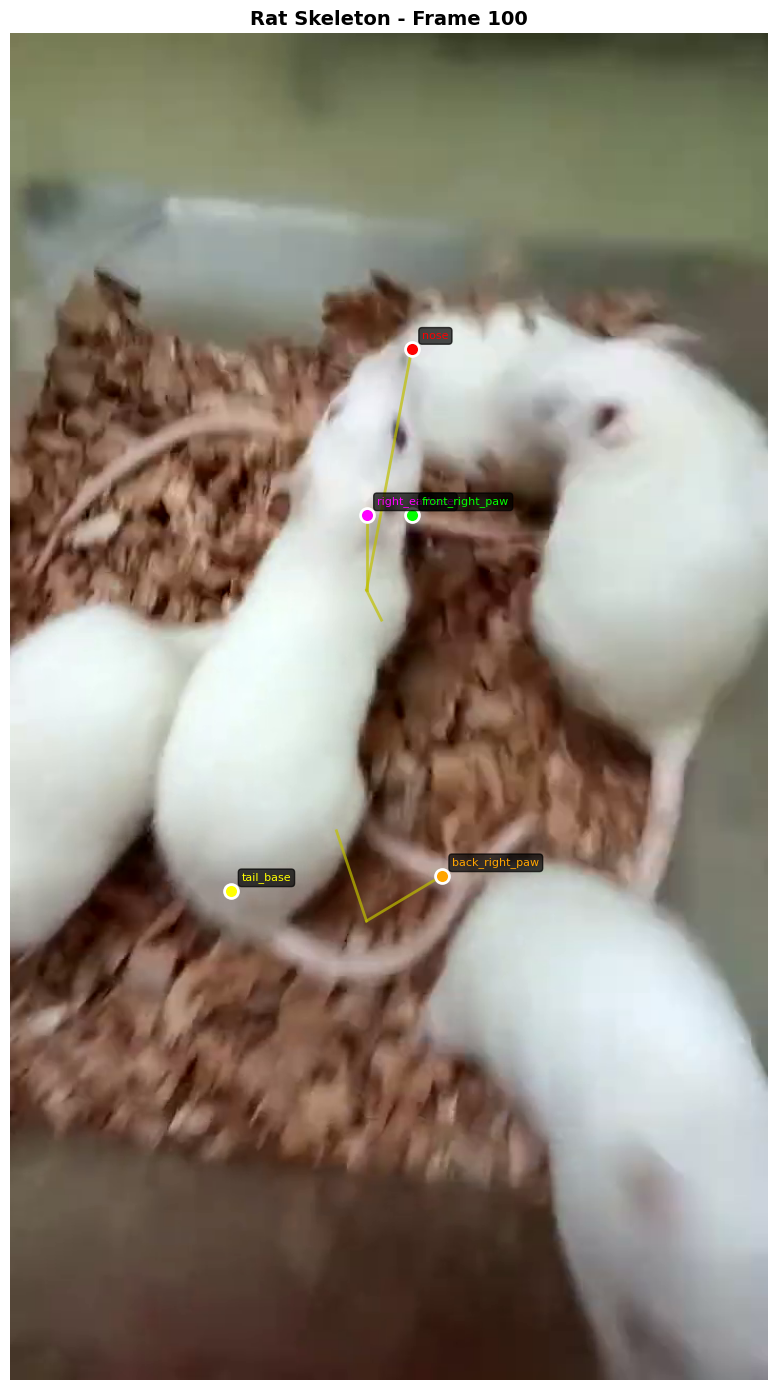

Saved: rat_skeleton_frame.png


In [ ]:
import cv2

# Load data
h5_file = '/content/Laboratory Rat Model (Wistar rats)_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_.h5'
df = pd.read_hdf(h5_file)
scorer = 'superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_'

# Load a frame from the video
video_path = '/content/Laboratory Rat Model (Wistar rats) (1).mp4'
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)  # Frame 100
ret, frame = cap.read()
cap.release()

# Get predictions for this frame
frame_data = df.iloc[100]
animal_data = frame_data[scorer]['animal0']

# Define skeleton connections (which points connect)
skeleton = [
    ('nose', 'neck_base'),
    ('neck_base', 'neck_end'),
    ('neck_end', 'back_base'),
    ('back_base', 'back_middle'),
    ('back_middle', 'back_end'),
    ('back_end', 'tail_base'),
    ('tail_base', 'tail_end'),

    # Ears
    ('neck_base', 'left_earbase'),
    ('left_earbase', 'left_earend'),
    ('neck_base', 'right_earbase'),
    ('right_earbase', 'right_earend'),

    # Front legs
    ('neck_end', 'front_left_thai'),
    ('front_left_thai', 'front_left_knee'),
    ('front_left_knee', 'front_left_paw'),

    ('neck_end', 'front_right_thai'),
    ('front_right_thai', 'front_right_knee'),
    ('front_right_knee', 'front_right_paw'),

    # Back legs
    ('back_middle', 'back_left_thai'),
    ('back_left_thai', 'back_left_knee'),
    ('back_left_knee', 'back_left_paw'),

    ('back_middle', 'back_right_thai'),
    ('back_right_thai', 'back_right_knee'),
    ('back_right_knee', 'back_right_paw'),
]

# Plot frame
plt.figure(figsize=(8, 14))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Draw skeleton lines
confidence_threshold = 0.3
for bp1, bp2 in skeleton:
    try:
        # Get coordinates
        x1 = animal_data[bp1]['x']
        y1 = animal_data[bp1]['y']
        conf1 = animal_data[bp1]['likelihood']

        x2 = animal_data[bp2]['x']
        y2 = animal_data[bp2]['y']
        conf2 = animal_data[bp2]['likelihood']

        # Only draw if both points are confident
        if conf1 > confidence_threshold and conf2 > confidence_threshold:
            plt.plot([x1, x2], [y1, y2], 'y-', linewidth=2, alpha=0.7)
    except:
        continue

# Draw keypoints on top
bodyparts = ['nose', 'left_earbase', 'right_earbase', 'front_left_paw', 'front_right_paw',
             'back_left_paw', 'back_right_paw', 'tail_base', 'tail_end']

colors = {
    'nose': 'red',
    'left_earbase': 'cyan',
    'right_earbase': 'magenta',
    'front_left_paw': 'lime',
    'front_right_paw': 'lime',
    'back_left_paw': 'orange',
    'back_right_paw': 'orange',
    'tail_base': 'yellow',
    'tail_end': 'yellow'
}

for bp in bodyparts:
    try:
        x = animal_data[bp]['x']
        y = animal_data[bp]['y']
        likelihood = animal_data[bp]['likelihood']

        if likelihood > confidence_threshold:
            color = colors.get(bp, 'white')
            plt.plot(x, y, 'o', color=color, markersize=10,
                    markeredgecolor='white', markeredgewidth=2)
            plt.text(x+10, y-10, f'{bp}', fontsize=8, color=color,
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    except:
        continue

plt.title('Rat Skeleton - Frame 100', fontsize=14, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('rat_skeleton_frame.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: rat_skeleton_frame.png")